# Patient Profile Creation

Install required packages

In [1]:
!pip install -q scikit-learn scipy

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
import logging
from sklearn.preprocessing import StandardScaler, RobustScaler
from scipy import stats

In [3]:
# Configure paths
notebook_dir = Path().resolve()
FEATURE_PATH = notebook_dir.parents[1] / "1" / "Features"

# Feature file names
FILES_CONFIG = {
    'laboratory_tests': 'laboratory_tests_features.csv',
    'procedures': 'procedure_code_features.csv',
    'heart_diagnoses': 'heart_diagnoses_features.csv',
    'microbiology': 'microbiology_events_features.csv'
}

print(f"Feature Path: {FEATURE_PATH}")
print(f"Configuration loaded")

Feature Path: /home/gabriele/DAD/project/Tasks/1/Features
Configuration loaded


In [4]:
# Load all feature tables
dfs = {}
for key, filename in FILES_CONFIG.items():
    filepath = FEATURE_PATH / filename
    dfs[key] = pd.read_csv(filepath)
    print(f"\n{key.upper()}")
    print(f"  Shape: {dfs[key].shape}")
    print(f"  Columns: {list(dfs[key].columns)[:5]}...")


LABORATORY_TESTS
  Shape: (4751, 32)
  Columns: ['hadm_id', 'total_tests', 'n_invalid', 'tests_days_span', 'perc_invalid']...

PROCEDURES
  Shape: (3459, 5)
  Columns: ['subject_id', 'hadm_id', 'total_procedures', 'unique_procedures', 'procedures_days_span']...

HEART_DIAGNOSES
  Shape: (4864, 19)
  Columns: ['subject_id', 'hadm_id', 'age', 'gender', 'temperature']...

MICROBIOLOGY
  Shape: (2756, 3)
  Columns: ['subject_id', 'hadm_id', 'infection_severity_score']...


## Data Merging

In [5]:
print("\nHeart Diagnoses + Microbiology")

# Merge heart diagnoses with microbiology
heart_microbiology = pd.merge(
    dfs['heart_diagnoses'],
    dfs['microbiology'],
    on=['subject_id', 'hadm_id'],
    how='outer',
    suffixes=('_heart', '_microbio')
)

print(f" Heart + Microbiology shape: {heart_microbiology.shape}")
print(f"   Unique patients: {heart_microbiology['subject_id'].nunique()}")


Heart Diagnoses + Microbiology
 Heart + Microbiology shape: (5166, 20)
   Unique patients: 4694


In [6]:
print("\nAdd Procedures")

# merge with procedures
heart_micro_procedures = pd.merge(
    heart_microbiology,
    dfs['procedures'],
    on=['subject_id', 'hadm_id'],
    how='outer',
    suffixes=('', '_proc')
)

print(f" Heart + Microbiology + Procedures shape: {heart_micro_procedures.shape}")
print(f"Unique patients: {heart_micro_procedures['subject_id'].nunique()}")


Add Procedures
 Heart + Microbiology + Procedures shape: (5166, 23)
Unique patients: 4694


In [7]:
# Merge with laboratory tests
patient_admissions = pd.merge(
    heart_micro_procedures,
    dfs['laboratory_tests'],
    on='hadm_id',
    how='outer',
    suffixes=('', '_lab')
)

patient_admissions['hadm_id'] = patient_admissions['hadm_id'].astype('Int64')

print(f"  Final merged shape: {patient_admissions.shape}")
print(f"  Unique patients: {patient_admissions['subject_id'].nunique()}")
print(f"  Total admissions: {patient_admissions['hadm_id'].nunique()}")

  Final merged shape: (5166, 54)
  Unique patients: 4694
  Total admissions: 4761


In [8]:
patient_admissions.head()

,subject_id,hadm_id,age,gender,temperature,bp_systolic,bp_diastolic,heart_rate,respiratory_rate,oxygen_saturation,...,creat_n,creat_n_abnormal,creat_abnormal_ratio,glu_min,glu_max,glu_n,glu_n_abnormal,glu_abnormal_ratio,glu_var,na_cl_ratio
0,12869457,20004456,NaN,NaN,NaN,NaN,NaN,NaN,NaN,92.0,...,3.0,3.0,1.000,125.0,193.0,3.0,3.0,1.00,36.94,1.33
1,13709807,20007905,NaN,NaN,NaN,135.0,62.0,127.0,29.0,93.0,...,7.0,1.0,0.143,231.0,314.0,6.0,6.0,1.00,29.85,1.40
2,19997460,20007905,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,7.0,1.0,0.143,231.0,314.0,6.0,6.0,1.00,29.85,1.40
3,19997485,20007905,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,7.0,1.0,0.143,231.0,314.0,6.0,6.0,1.00,29.85,1.40
4,12002285,20013519,NaN,NaN,NaN,NaN,NaN,NaN,NaN,99.0,...,4.0,4.0,1.000,74.0,104.0,4.0,1.0,0.25,13.74,1.35


In [9]:
patient_admissions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5166 entries, 0 to 5165
Data columns (total 54 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   subject_id                     5166 non-null   int64  
 1   hadm_id                        5166 non-null   Int64  
 2   age                            1363 non-null   float64
 3   gender                         1363 non-null   object 
 4   temperature                    2426 non-null   float64
 5   bp_systolic                    2383 non-null   float64
 6   bp_diastolic                   2383 non-null   float64
 7   heart_rate                     2255 non-null   float64
 8   respiratory_rate               2178 non-null   float64
 9   oxygen_saturation              3894 non-null   float64
 10  heart_failure_severity_score   1551 non-null   float64
 11  cad_severity_score             2531 non-null   float64
 12  valvular_disease_score         4285 non-null   f

## Aggregation of the features at patient level

In this phase, we aggregate the measure reported at admission level to form a patient-wise report. 

For creating the patient profile, we use aggregation rules for the creation of patient-wise features which aggregates measures taken from patient's admission  

In [10]:
# Categorize features by aggregation method
aggregation_rules = {
    # ========== IDENTIFIERS ==========
    'subject_id': 'first',  # Keep patient ID
    
    # ========== DEMOGRAPHICS (take from any admission) ==========
    'age': 'first',         # Age should be consistent across admissions
    'gender': 'first',      # Gender is constant
    
    # ========== CONTINUOUS FEATURES (worst value) ==========
    # For clinical severity: take WORST value across admissions
    'temperature': 'max',           # Fever = worse
    'bp_systolic': 'mean',          # Average BP more stable
    'bp_diastolic': 'mean',
    'heart_rate': 'max',            # Tachycardia = worse
    'respiratory_rate': 'max',      # Tachypnea = worse
    'oxygen_saturation': 'min',     # Hypoxia = worse (lower is worse)
    
    # ========== COMPOSITE SCORES (worst) ==========
    'heart_failure_severity_score': 'max',
    'cad_severity_score': 'max',
    'valvular_disease_score': 'max',
    'ecg_abnormality_score': 'max',
    'respiratory_distress_score': 'max',
    'exam_abnormality_score': 'max',
    'ct_complications_score': 'max',
    'cardiac_remodeling_score': 'max',
    'stenosis_severity_score': 'max',
    'hemodynamic_instability_score': 'max',
    
    # ========== LABORATORY TESTS (aggregate) ==========
    'total_tests': 'sum',           # Total across all admissions
    'n_invalid': 'sum',             # Total abnormal tests
    'tests_days_span': 'sum',       # Total monitoring days
    'perc_invalid': 'mean',         # Average abnormality rate
    
    # Electrolytes (worst values)
    'k_min': 'min',
    'k_max': 'max',
    'k_n': 'sum',
    'k_abnormal_ratio': 'mean',
    
    'na_min': 'min',
    'na_max': 'max',
    'na_n': 'sum',
    'na_abnormal_ratio': 'mean',
    
    'cl_min': 'min',
    'cl_max': 'max',
    'cl_n': 'sum',
    'cl_abnormal_ratio': 'mean',
    
    'creat_max': 'max',             # Worst kidney function
    'creat_n': 'sum',
    'creat_abnormal_ratio': 'mean',
    
    'glu_max': 'max',               # Worst glucose control
    'glu_n': 'sum',
    'glu_abnormal_ratio': 'mean',
    'glu_var': 'mean',              # Average variability
    
    'na_cl_ratio': 'mean',
    
    # ========== PROCEDURES (aggregate) ==========
    'total_procedures': 'sum',      # Total procedures across admissions
    'unique_procedures': 'sum',     # Sum of unique procedures
    'procedures_days_span': 'sum',
    
    # ========== MICROBIOLOGY (aggregate) ==========
    'infection_severity_score': 'max',     # Worst severity score
    
}

# Count aggregation strategies
agg_counts = pd.Series(aggregation_rules.values()).value_counts()
print("\nAggregation strategy distribution:")
for method, count in agg_counts.items():
    print(f"  • {method}: {count} features")


Aggregation strategy distribution:
  • max: 19 features
  • sum: 11 features
  • mean: 10 features
  • min: 4 features
  • first: 3 features


Now, we apply this aggregation:

In [11]:
# Filter rules to only include columns present in dataset
valid_rules = {col: method for col, method in aggregation_rules.items() 
               if col in patient_admissions.columns}

print(f"\nFeatures to aggregate: {len(valid_rules)}")
print(f"Features not in dataset: {len(aggregation_rules) - len(valid_rules)}")

# Group by patient and aggregate
patient_profiles = patient_admissions.groupby('subject_id').agg(valid_rules).reset_index(drop=True)

print(f"\n Patient-wise aggregation completed")
print(f"   Original shape (admission-level): {patient_admissions.shape}")
print(f"   Aggregated shape (patient-level): {patient_profiles.shape}")
print(f"   Features per patient: {patient_profiles.shape[1]}")


Features to aggregate: 46
Features not in dataset: 1

 Patient-wise aggregation completed
   Original shape (admission-level): (5166, 54)
   Aggregated shape (patient-level): (4694, 46)
   Features per patient: 46


In [12]:
patient_profiles.head()

,subject_id,age,gender,temperature,bp_systolic,bp_diastolic,heart_rate,respiratory_rate,oxygen_saturation,heart_failure_severity_score,...,creat_abnormal_ratio,glu_max,glu_n,glu_abnormal_ratio,glu_var,na_cl_ratio,total_procedures,unique_procedures,procedures_days_span,infection_severity_score
0,10000980,75.0,F,36.7,200.0,103.0,65.0,26.0,100.0,3.0,...,1.000,163.0,9.0,0.6785,29.57,1.325,7.0,7.0,0.0,0.0
1,10002013,NaN,None,37.4,157.0,88.0,118.0,24.0,96.0,NaN,...,0.000,395.0,2.0,1.0000,16.26,1.380,2.0,2.0,0.0,NaN
2,10002155,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.188,140.0,16.0,0.6880,10.26,1.340,8.0,8.0,14.0,0.0
3,10004457,66.0,M,NaN,NaN,NaN,NaN,NaN,98.0,0.0,...,0.000,92.0,1.0,0.0000,NaN,1.360,0.0,0.0,0.0,NaN
4,10007058,48.0,M,36.8,123.0,71.0,63.0,21.0,99.0,0.0,...,0.000,111.0,5.0,0.8000,7.19,1.340,2.0,2.0,0.0,0.0


## Data Quality Assessment

### Missing values analysis

We calculate missing percentage for each feature

We divide the features into:
- "good" if they have < 20% missing values
- "moderate" if they have a missing rate between 20% and 40%
- "risky" otherwise

In [13]:
# Define thresholds
THRESHOLD_RISKY = 40      # >40% = risky
THRESHOLD_MODERATE = 20   # 20-40% = moderate
# <20% = good

# Missing data analysis
missing_stats = pd.DataFrame({
    'Feature': patient_profiles.columns,
    'Missing_Count': patient_profiles.isnull().sum(),
    'Missing_Pct': (patient_profiles.isnull().sum() / len(patient_profiles) * 100).round(2)
}).sort_values('Missing_Pct', ascending=False)

print(f"  Features with NO missing: {(missing_stats['Missing_Count'] == 0).sum()}")
print(f"  Features with <20% missing: {(missing_stats['Missing_Pct'] < THRESHOLD_MODERATE).sum()}")
print(f"  Features with >40% missing: {(missing_stats['Missing_Pct'] > THRESHOLD_RISKY).sum()}")


  Features with NO missing: 12
  Features with <20% missing: 33
  Features with >40% missing: 11


In [14]:
missing_stats['Category'] = pd.cut(
    missing_stats['Missing_Pct'],
    bins=[-0.1, THRESHOLD_MODERATE, THRESHOLD_RISKY, 100],
    labels=['GOOD', 'MODERATE', 'RISKY']
)

In [15]:
# Show top missing features
print("\nTop 15 features with missing data:")
print(missing_stats[missing_stats['Missing_Count'] > 0].head(15).to_string(index=False))


Top 15 features with missing data:
                     Feature  Missing_Count  Missing_Pct Category
                         age           3430        73.07    RISKY
                      gender           3430        73.07    RISKY
heart_failure_severity_score           3189        67.94    RISKY
      ct_complications_score           3068        65.36    RISKY
            respiratory_rate           2630        56.03    RISKY
                  heart_rate           2564        54.62    RISKY
                 bp_systolic           2455        52.30    RISKY
                bp_diastolic           2455        52.30    RISKY
                 temperature           2417        51.49    RISKY
          cad_severity_score           2299        48.98    RISKY
    infection_severity_score           2078        44.27    RISKY
       ecg_abnormality_score           1671        35.60 MODERATE
           oxygen_saturation           1133        24.14 MODERATE
      valvular_disease_score            

### Features removal

We can delete the "risky" features which have a lot of missing values because they are not informative to us at patient level. 

In [16]:
exclude_features = ['subject_id', 'hadm_id', 'dod']

In [17]:
good_features = missing_stats[
    (missing_stats['Category'] == 'GOOD') & 
    (~missing_stats['Feature'].isin(exclude_features))
]['Feature'].tolist()

moderate_features = missing_stats[
    (missing_stats['Category'] == 'MODERATE') & 
    (~missing_stats['Feature'].isin(exclude_features))
]['Feature'].tolist()

risky_features = missing_stats[
    (missing_stats['Category'] == 'RISKY') & 
    (~missing_stats['Feature'].isin(exclude_features))
]['Feature'].tolist()

In [18]:
critical_moderate = {
    'atrial_fibrillation': 'Strong mortality predictor',
    'lbbb': 'Heart failure marker',
    'st_elevation': 'Acute MI indicator',
    'st_depression': 'Ischemia marker',
    'oxygen_saturation': 'Vital sign',
    'q_waves': 'Old MI marker',
    'temperature': 'Vital sign'
}

moderate_to_keep = [f for f in moderate_features if f in critical_moderate]
moderate_to_remove = [f for f in moderate_features if f not in critical_moderate]

In [19]:
features_to_keep = good_features + moderate_to_keep
features_to_remove = risky_features + moderate_to_remove

In [20]:
df_filtered = patient_profiles[['subject_id'] + features_to_keep].copy()


### Handling missing values on moderate and good features

#### Identify feature types (binary vs continuous)

In [21]:
binary_features = []
continuous_features = []

for col in features_to_keep:
    if col in df_filtered.columns:
        # Check unique non-null values
        unique_vals = df_filtered[col].dropna().unique()
        
        # Binary: only 0 and 1 (or True/False)
        if len(unique_vals) <= 2:
            if all(v in [0, 1, 0.0, 1.0, True, False] for v in unique_vals):
                binary_features.append(col)
            else:
                continuous_features.append(col)
        else:
            continuous_features.append(col)

In [22]:
print("\n   Continuous features (sample):")
for feat in continuous_features[:10]:
    n_missing = df_filtered[feat].isnull().sum()
    print(f"      • {feat:<40} {n_missing} missing")
if len(continuous_features) > 10:
    print(f"      ... and {len(continuous_features)-10} more")


   Continuous features (sample):
      • valvular_disease_score                   768 missing
      • cardiac_remodeling_score                 768 missing
      • glu_var                                  349 missing
      • exam_abnormality_score                   302 missing
      • respiratory_distress_score               302 missing
      • hemodynamic_instability_score            302 missing
      • glu_abnormal_ratio                       30 missing
      • glu_max                                  30 missing
      • cl_max                                   23 missing
      • na_abnormal_ratio                        23 missing
      ... and 23 more


#### add missingness indicators for moderate features

In [23]:
missingness_indicators = []

for feature in moderate_to_keep:
    if feature in df_filtered.columns:
        # Create indicator: 1 = measured, 0 = not measured
        indicator_name = f'{feature}_measured'
        df_filtered[indicator_name] = (~df_filtered[feature].isnull()).astype(int)
        missingness_indicators.append(indicator_name)
        
        measured = df_filtered[indicator_name].sum()
        not_measured = len(df_filtered) - measured
        
        print(f"  ✓ {indicator_name}")
        print(f"     Measured: {measured} ({measured/len(df_filtered)*100:.1f}%)")
        print(f"     Not measured: {not_measured} ({not_measured/len(df_filtered)*100:.1f}%)")
        
df_filtered.drop(columns=missingness_indicators, inplace=True)

  ✓ oxygen_saturation_measured
     Measured: 3561 (75.9%)
     Not measured: 1133 (24.1%)


Now we can impute missing values.

Let's start from binary features...

In [24]:
binary_imputation_log = []

for col in binary_features:
    if col in df_filtered.columns:
        n_missing = df_filtered[col].isnull().sum()
        
        if n_missing > 0:
            # Calculate mode
            mode_val = df_filtered[col].mode()[0] if not df_filtered[col].mode().empty else 0
            
            # Impute
            df_filtered[col].fillna(mode_val, inplace=True)
            
            binary_imputation_log.append({
                'Feature': col,
                'Missing_Count': n_missing,
                'Imputed_Value': mode_val
            })
            
            print(f"{col:<40} {n_missing:>4} missing → {int(mode_val)}")

print(f"\nImputed {len(binary_imputation_log)} binary features")


Imputed 0 binary features


And continue with continuous features: we use KNN imputer if there is possibility, otherwise we use median fallback

In [25]:
from sklearn.impute import KNNImputer


if len(continuous_features) > 0:
    continuous_data = df_filtered[continuous_features].copy()
    for col in continuous_data.columns:
        if continuous_data[col].dtype == 'object':
            try:
                continuous_data[col] = pd.to_numeric(continuous_data[col])
            except:
                continuous_features.remove(col)
    
    missing_before = continuous_data.isnull().sum()
    features_with_missing = missing_before[missing_before > 0]
    
    print(f"Features requiring imputation: {len(features_with_missing)}\n")
    
    # KNN Imputation
    knn_imputer = KNNImputer(n_neighbors=5, weights='distance')
    
    try:
        continuous_imputed = knn_imputer.fit_transform(continuous_data)
        
        # Update dataframe
        df_filtered[continuous_features] = continuous_imputed
        
        # Log imputation
        for feat in features_with_missing.index:
            print(f"  ✓ {feat:<40} {missing_before[feat]:>4} missing → KNN imputed")
        
        print(f"\nKNN imputation completed for {len(features_with_missing)} continuous features")
        print(f"   Method: k=5 nearest neighbors with distance weighting")
        
    except Exception as e:
        print(f"\nKNN imputation failed: {str(e)}")
        print("   Falling back to median imputation...")
        
        # Fallback: median imputation
        for col in continuous_features:
            if df_filtered[col].isnull().any():
                median_val = df_filtered[col].median()
                df_filtered[col].fillna(median_val, inplace=True)
                print(f"  ✓ {col:<40} imputed with median: {median_val:.2f}")
else:
    print("No continuous features requiring imputation")

Features requiring imputation: 22

  ✓ valvular_disease_score                    768 missing → KNN imputed
  ✓ cardiac_remodeling_score                  768 missing → KNN imputed
  ✓ glu_var                                   349 missing → KNN imputed
  ✓ exam_abnormality_score                    302 missing → KNN imputed
  ✓ respiratory_distress_score                302 missing → KNN imputed
  ✓ hemodynamic_instability_score             302 missing → KNN imputed
  ✓ glu_abnormal_ratio                         30 missing → KNN imputed
  ✓ glu_max                                    30 missing → KNN imputed
  ✓ cl_max                                     23 missing → KNN imputed
  ✓ na_abnormal_ratio                          23 missing → KNN imputed
  ✓ cl_abnormal_ratio                          23 missing → KNN imputed
  ✓ cl_min                                     23 missing → KNN imputed
  ✓ na_cl_ratio                                23 missing → KNN imputed
  ✓ na_max                   

In [26]:
imputed_df = pd.DataFrame(
    continuous_imputed, 
    columns=continuous_features,
    index=continuous_data.index
)

for col in continuous_features:
    non_null_values = continuous_data[col].dropna()
    if len(non_null_values) > 0:
        decimals = non_null_values.apply(
            lambda x: len(str(x).split('.')[-1]) if '.' in str(x) else 0
        ).max()
        decimals = min(decimals, 3)
        imputed_df[col] = imputed_df[col].round(decimals)

df_filtered[continuous_features] = imputed_df


In [27]:
patient_profiles = df_filtered.copy()

## Dimensionality Reduction

In [28]:
numeric_cols = patient_profiles.select_dtypes(include='number').columns
features_cols = [col for col in numeric_cols if col not in ['subject_id']]

In [29]:
# Create working dataframe
X = patient_profiles[features_cols].copy()

In [30]:
from sklearn.feature_selection import VarianceThreshold

sel = VarianceThreshold(threshold=0.01)
sel.fit(X)
low_variance_features = X.columns[~sel.get_support()].tolist()
print(f"\nLow variance features removed ({len(low_variance_features)}): {low_variance_features}")

X = X.loc[:, sel.get_support()]
print(f"After variance filter: {X.shape[1]} features")



Low variance features removed (1): ['na_cl_ratio']
After variance filter: 32 features


In [31]:
import numpy as np
corr_matrix = X.corr()
print(f"Correlation matrix: {corr_matrix.shape}")

Correlation matrix: (32, 32)


In [32]:
# Find High correlation feature pairs
def find_high_correlations(corr_matrix, threshold=0.8):
    high_corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) >= threshold:
                high_corr_pairs.append({
                    'feature_1': corr_matrix.columns[i],
                    'feature_2': corr_matrix.columns[j],
                    'correlation': corr_matrix.iloc[i, j]
                })
    return pd.DataFrame(high_corr_pairs).sort_values('correlation', key=abs, ascending=False)

In [33]:
high_corr = find_high_correlations(corr_matrix, threshold=0.8)
print(high_corr)

           feature_1          feature_2  correlation
21              na_n               cl_n     0.999273
19              na_n                k_n     0.995463
20              na_n            creat_n     0.994998
24               k_n               cl_n     0.994561
26           creat_n               cl_n     0.994504
23               k_n            creat_n     0.993729
29  total_procedures  unique_procedures     0.987854
1        total_tests          n_invalid     0.976185
7        total_tests              glu_n     0.974351
13         n_invalid              glu_n     0.948506
28              cl_n              glu_n     0.947803
27           creat_n              glu_n     0.946960
25               k_n              glu_n     0.946551
22              na_n              glu_n     0.945979
16   tests_days_span            creat_n     0.943066
15   tests_days_span                k_n     0.942398
14   tests_days_span               na_n     0.939304
17   tests_days_span               cl_n     0.

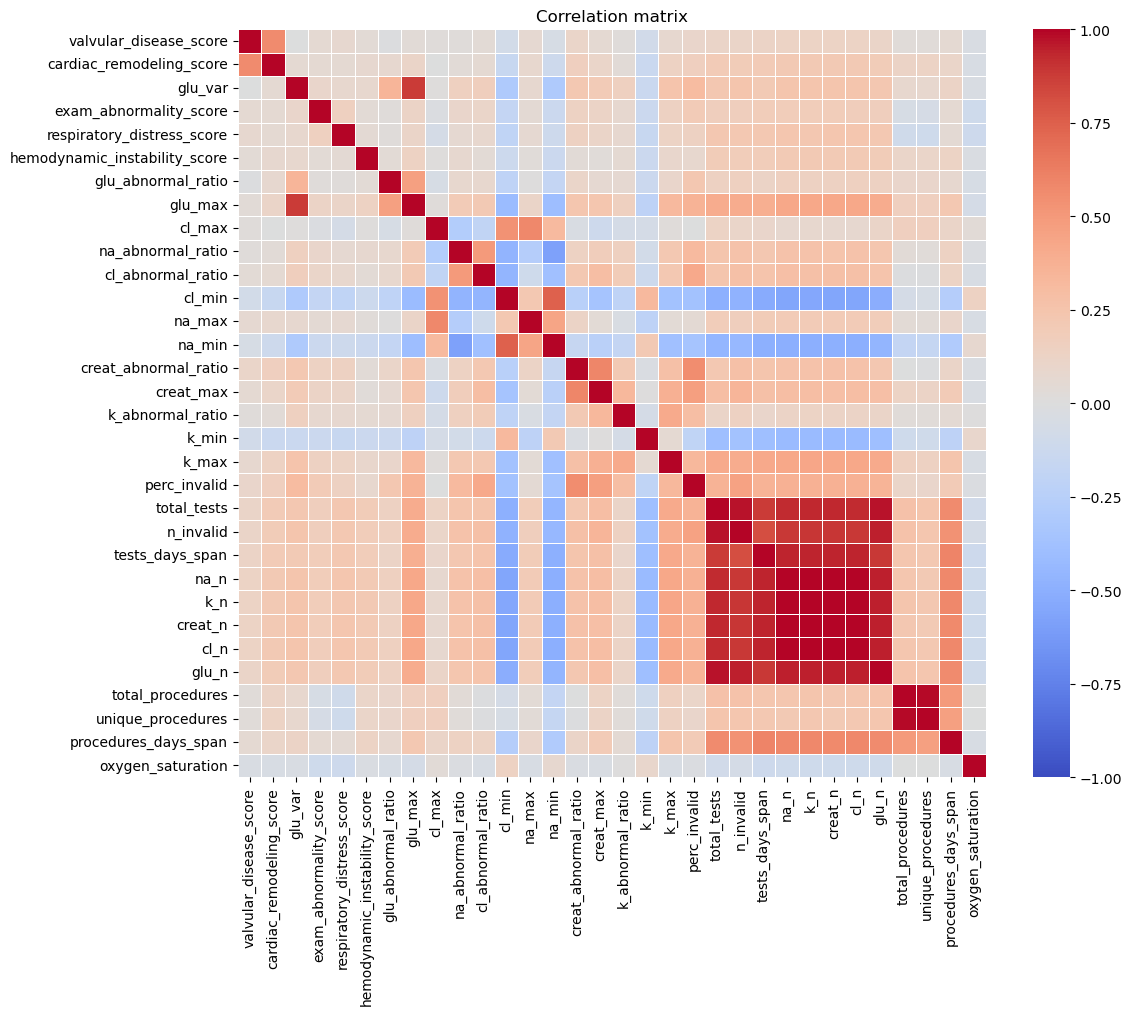

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Heatmap base
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, 
            annot=False,  
            cmap='coolwarm',
            center=0,
            vmin=-1, vmax=1,
            square=True,
            linewidths=0.5)
plt.title('Correlation matrix')
plt.tight_layout()
plt.show()


As we can see, there are lot of redundant features, so we have to choose which ones to keep and which ones to discard.

In [35]:
features_to_remove = set()
for _, row in high_corr.iterrows():
    features_to_remove.add(row['feature_2'])

print(f"\nRedundant features ({len(features_to_remove)}):")
for feature in sorted(features_to_remove):
    print(f"  - {feature}")


Redundant features (9):
  - cl_n
  - creat_n
  - glu_max
  - glu_n
  - k_n
  - n_invalid
  - na_n
  - tests_days_span
  - unique_procedures


In [36]:
import pandas as pd
from sklearn.feature_selection import VarianceThreshold

print(f"Starting features: {len(features_cols)}")
print(f"Features: {features_cols}")

#Remove highly correlated features (threshold 0.80)
corr = X.corr()
high_corr = set()
corr_pairs = []

for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if abs(corr.iloc[i, j]) > 0.80:
            corr_pairs.append((corr.columns[i], corr.columns[j], corr.iloc[i, j]))
            high_corr.add(corr.columns[j])  # Remove the second feature

print(f"\nHighly correlated pairs found (|r| > 0.80): {len(corr_pairs)}")
if len(corr_pairs) > 0:
    print("\nSome examples of high correlations:")
    for feat1, feat2, corr_val in sorted(corr_pairs, key=lambda x: abs(x[2]), reverse=True)[:10]:
        print(f"  {feat1} <-> {feat2}: {corr_val:.3f}")

print(f"\nFeatures to remove due to high correlation ({len(high_corr)}): {sorted(high_corr)}")

X = X.drop(columns=list(high_corr), errors='ignore')
print(f"\nAfter correlation filter: {X.shape[1]} features")

# Step 4: Create final dataset
final_features = ['subject_id'] + X.columns.tolist()
patient_profiles_clean = patient_profiles[final_features].copy()

Starting features: 33
Features: ['valvular_disease_score', 'cardiac_remodeling_score', 'glu_var', 'exam_abnormality_score', 'respiratory_distress_score', 'hemodynamic_instability_score', 'glu_abnormal_ratio', 'glu_max', 'cl_max', 'na_abnormal_ratio', 'cl_abnormal_ratio', 'cl_min', 'na_cl_ratio', 'na_max', 'na_min', 'creat_abnormal_ratio', 'creat_max', 'k_abnormal_ratio', 'k_min', 'k_max', 'perc_invalid', 'total_tests', 'n_invalid', 'tests_days_span', 'na_n', 'k_n', 'creat_n', 'cl_n', 'glu_n', 'total_procedures', 'unique_procedures', 'procedures_days_span', 'oxygen_saturation']

Highly correlated pairs found (|r| > 0.80): 30

Some examples of high correlations:
  na_n <-> cl_n: 0.999
  na_n <-> k_n: 0.995
  na_n <-> creat_n: 0.995
  k_n <-> cl_n: 0.995
  creat_n <-> cl_n: 0.995
  k_n <-> creat_n: 0.994
  total_procedures <-> unique_procedures: 0.988
  total_tests <-> n_invalid: 0.976
  total_tests <-> glu_n: 0.974
  n_invalid <-> glu_n: 0.949

Features to remove due to high correlation 

In [37]:
missing_counts = patient_profiles_clean.isna().sum()
missing_pct = (missing_counts / len(patient_profiles_clean) * 100).round(2)
missing_df = pd.DataFrame({
    'Feature': missing_counts.index,
    'Missing_Count': missing_counts.values,
    'Missing_Pct': missing_pct.values
}).sort_values('Missing_Pct', ascending=False)

In [38]:
missing_df[missing_df['Missing_Pct'] > 0].shape

(0, 3)

In [39]:
missing_df[missing_df['Missing_Pct'] > 0].head(15)

,Feature,Missing_Count,Missing_Pct


## Final dataset statistics

In [40]:
print("\n=== FINAL DATASET STATISTICS ===")

print(f"\n Patient Coverage:")
print(f"   Total unique patients: {patient_profiles['subject_id'].nunique()}")
print(f"   Complete cases (no missing): {patient_profiles.dropna().shape[0]}")

# Numeric summary
numeric_final = patient_profiles_clean.select_dtypes(include=[np.number])

print(f"\nNumeric Features Summary:")
summary_stats = numeric_final.describe().round(3)
print(summary_stats.iloc[[1, 2, 3, 4, 5, 7]].T.head(15))


=== FINAL DATASET STATISTICS ===

 Patient Coverage:
   Total unique patients: 4694
   Complete cases (no missing): 4694

Numeric Features Summary:
                                       mean          std         min  \
subject_id                     1.544012e+07  3089376.428  10000980.0   
valvular_disease_score         2.066000e+00        1.087         0.0   
cardiac_remodeling_score       2.412000e+00        1.668         0.0   
glu_var                        2.697800e+01       26.650         0.0   
exam_abnormality_score         2.192000e+00        1.031         0.0   
respiratory_distress_score     1.233000e+00        1.222         0.0   
hemodynamic_instability_score  1.420000e-01        0.547         0.0   
glu_abnormal_ratio             6.580000e-01        0.341         0.0   
cl_max                         1.046780e+02        4.551        83.0   
na_abnormal_ratio              8.400000e-02        0.197         0.0   
cl_abnormal_ratio              1.650000e-01        0.278   

### patient-wise features transformation

Before applying the transformations to the final patient-wise variables, we need to analyze their distribution to better understand what type of trasnformation they need.

In [41]:
columns_final = numeric_final.columns
features_cols = [c for c in columns_final if c != 'subject_id']
features_cols

['valvular_disease_score',
 'cardiac_remodeling_score',
 'glu_var',
 'exam_abnormality_score',
 'respiratory_distress_score',
 'hemodynamic_instability_score',
 'glu_abnormal_ratio',
 'cl_max',
 'na_abnormal_ratio',
 'cl_abnormal_ratio',
 'cl_min',
 'na_max',
 'na_min',
 'creat_abnormal_ratio',
 'creat_max',
 'k_abnormal_ratio',
 'k_min',
 'k_max',
 'perc_invalid',
 'total_tests',
 'total_procedures',
 'procedures_days_span',
 'oxygen_saturation']

We divide the features we have for clinical purposes: 


In [42]:
feature_groups = {
    'Composite Clinical Scores': [
        'valvular_disease_score',
        'cardiac_remodeling_score',
        'exam_abnormality_score',
        'respiratory_distress_score',
        'hemodynamic_instability_score'
    ],
    
    'Electrolytes - Extreme Values': [
        'na_min',
        'na_max',
        'k_min',
        'k_max',
        'cl_min',
        'cl_max'
    ],
    
    'Electrolytes - Abnormal Ratios': [
        'na_abnormal_ratio',
        'k_abnormal_ratio',
        'cl_abnormal_ratio'
    ],
    
    'Renal Function': [
        'creat_max',
        'creat_abnormal_ratio'
    ],
    
    'Glucose Metabolism': [
        'glu_var',
        'glu_abnormal_ratio'
    ],
    
    'Oxygenation': [
        'oxygen_saturation'
    ],
    
    'Healthcare Utilization': [
        'total_tests',
        'total_procedures',
        'procedures_days_span'
    ],
    
    'Data Quality': [
        'perc_invalid'
    ]
}

Now we can visualize the distributions of the clinical features groups

/tmp/ipykernel_99669/515726874.py:51: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/gabriele/miniconda3/envs/DADH/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


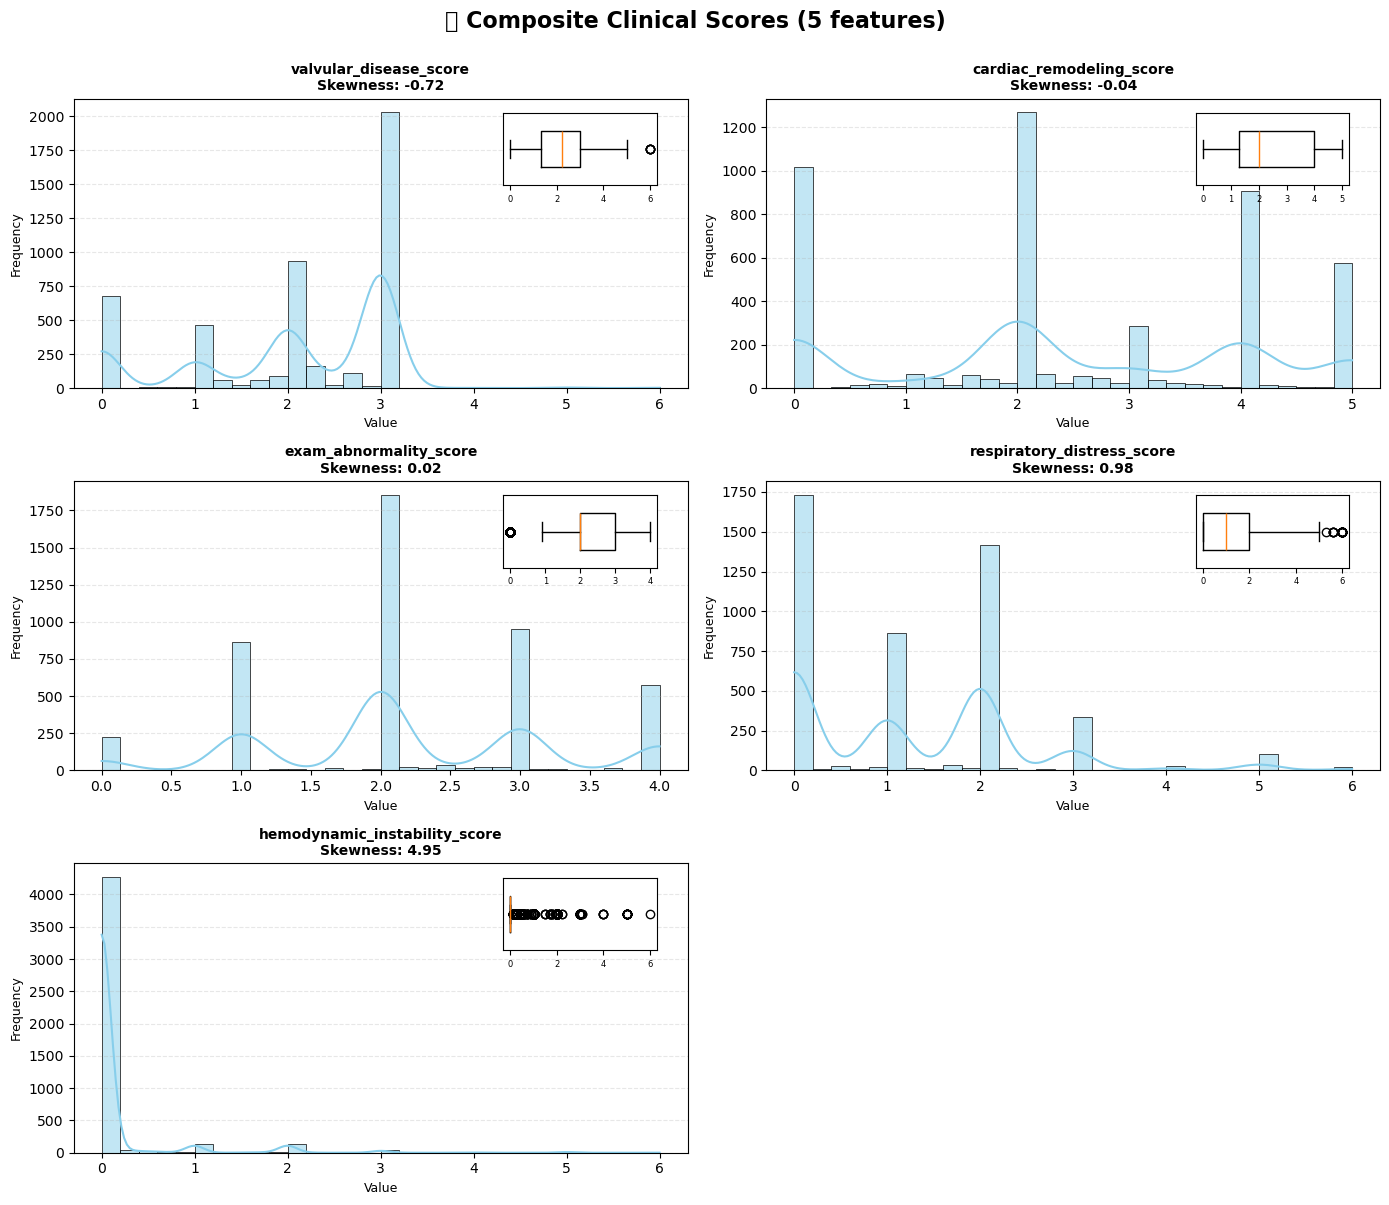


Group: Composite Clinical Scores

valvular_disease_score:
  • N values: 4694
  • Range: [0.00, 6.00]
  • Mean: 2.07 ± 1.09
  • Median: 2.20
  • Skewness: -0.72
  • % NaN: 0.0%

cardiac_remodeling_score:
  • N values: 4694
  • Range: [0.00, 5.00]
  • Mean: 2.41 ± 1.67
  • Median: 2.00
  • Skewness: -0.04
  • % NaN: 0.0%

exam_abnormality_score:
  • N values: 4694
  • Range: [0.00, 4.00]
  • Mean: 2.19 ± 1.03
  • Median: 2.00
  • Skewness: 0.02
  • % NaN: 0.0%

respiratory_distress_score:
  • N values: 4694
  • Range: [0.00, 6.00]
  • Mean: 1.23 ± 1.22
  • Median: 1.00
  • Skewness: 0.98
  • % NaN: 0.0%

hemodynamic_instability_score:
  • N values: 4694
  • Range: [0.00, 6.00]
  • Mean: 0.14 ± 0.55
  • Median: 0.00
  • Skewness: 4.95
  • % NaN: 0.0%




/tmp/ipykernel_99669/515726874.py:51: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/gabriele/miniconda3/envs/DADH/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


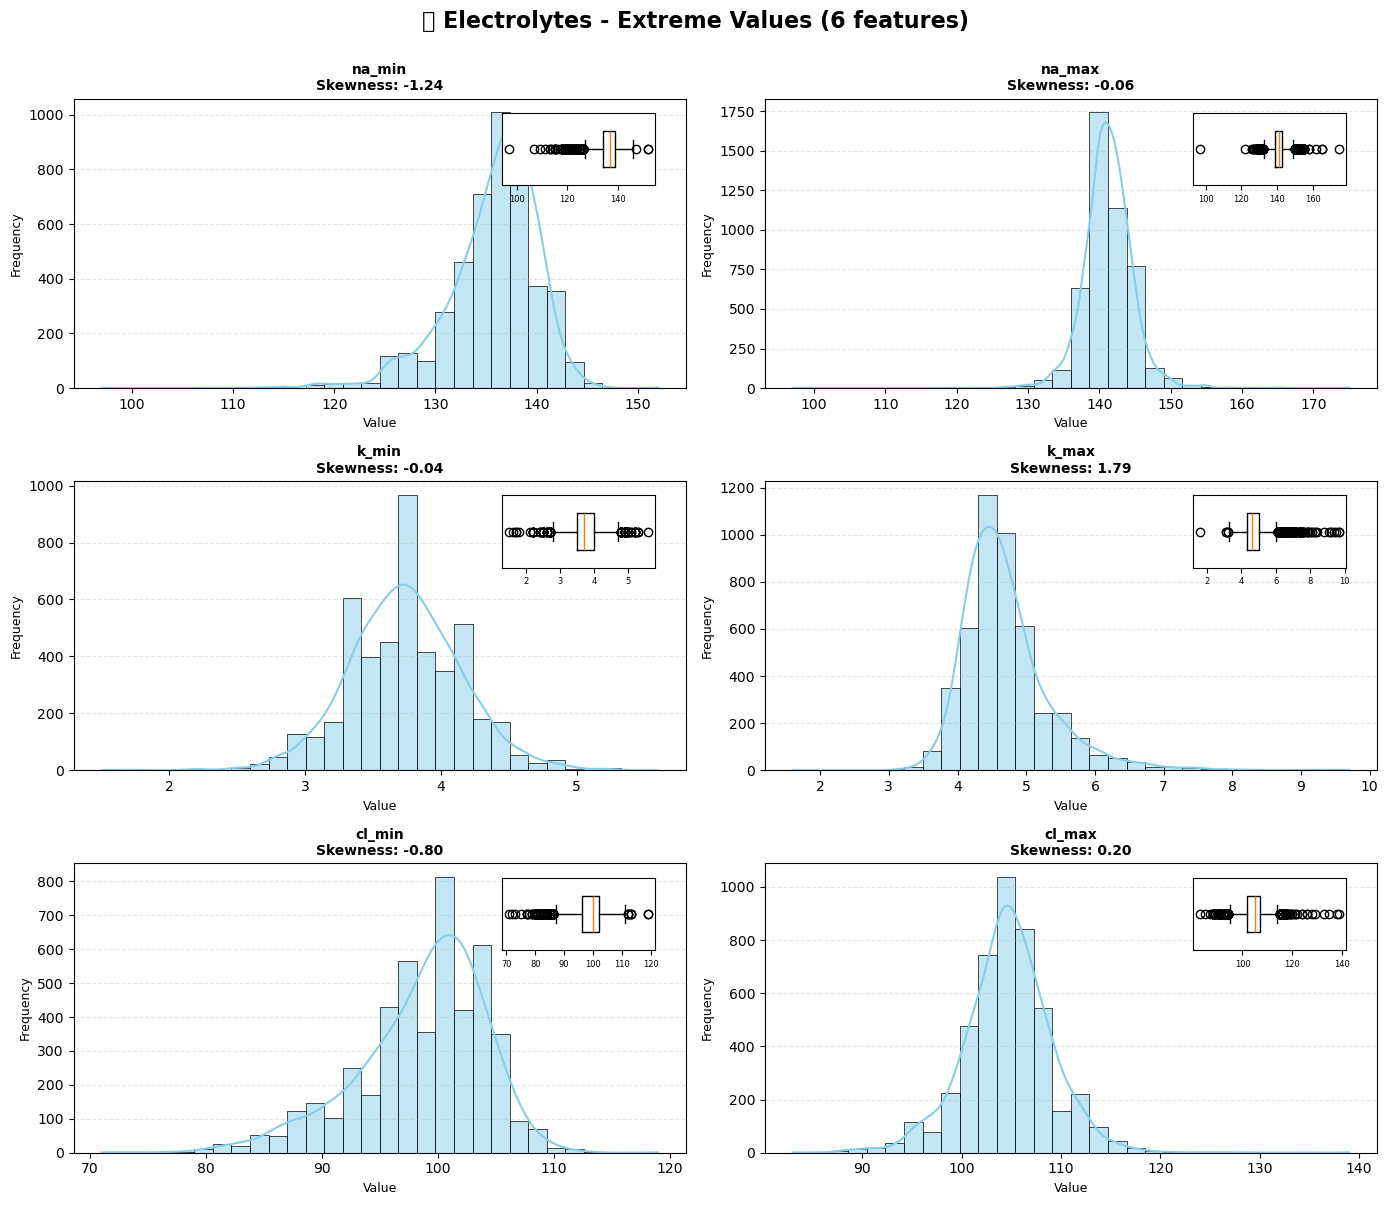


Group: Electrolytes - Extreme Values

na_min:
  • N values: 4694
  • Range: [97.00, 152.00]
  • Mean: 135.74 ± 4.49
  • Median: 137.00
  • Skewness: -1.24
  • % NaN: 0.0%

na_max:
  • N values: 4694
  • Range: [97.00, 175.00]
  • Mean: 141.21 ± 3.46
  • Median: 141.00
  • Skewness: -0.06
  • % NaN: 0.0%

k_min:
  • N values: 4694
  • Range: [1.50, 5.60]
  • Mean: 3.73 ± 0.42
  • Median: 3.70
  • Skewness: -0.04
  • % NaN: 0.0%

k_max:
  • N values: 4694
  • Range: [1.60, 9.70]
  • Mean: 4.70 ± 0.66
  • Median: 4.60
  • Skewness: 1.79
  • % NaN: 0.0%

cl_min:
  • N values: 4694
  • Range: [71.00, 119.00]
  • Mean: 98.63 ± 5.58
  • Median: 100.00
  • Skewness: -0.80
  • % NaN: 0.0%

cl_max:
  • N values: 4694
  • Range: [83.00, 139.00]
  • Mean: 104.68 ± 4.55
  • Median: 105.00
  • Skewness: 0.20
  • % NaN: 0.0%




/tmp/ipykernel_99669/515726874.py:51: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/gabriele/miniconda3/envs/DADH/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


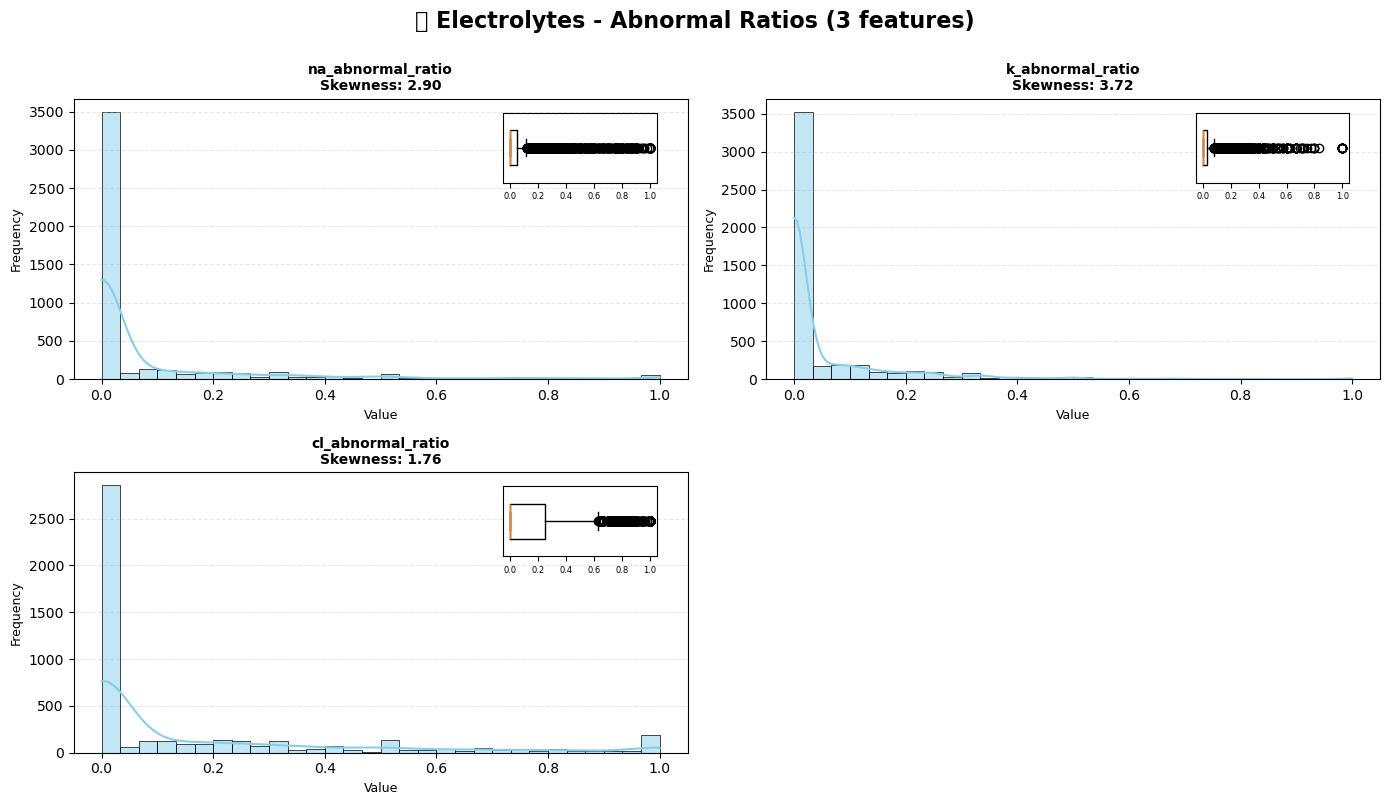


Group: Electrolytes - Abnormal Ratios

na_abnormal_ratio:
  • N values: 4694
  • Range: [0.00, 1.00]
  • Mean: 0.08 ± 0.20
  • Median: 0.00
  • Skewness: 2.90
  • % NaN: 0.0%

k_abnormal_ratio:
  • N values: 4694
  • Range: [0.00, 1.00]
  • Mean: 0.05 ± 0.12
  • Median: 0.00
  • Skewness: 3.72
  • % NaN: 0.0%

cl_abnormal_ratio:
  • N values: 4694
  • Range: [0.00, 1.00]
  • Mean: 0.17 ± 0.28
  • Median: 0.00
  • Skewness: 1.76
  • % NaN: 0.0%




/tmp/ipykernel_99669/515726874.py:51: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/gabriele/miniconda3/envs/DADH/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


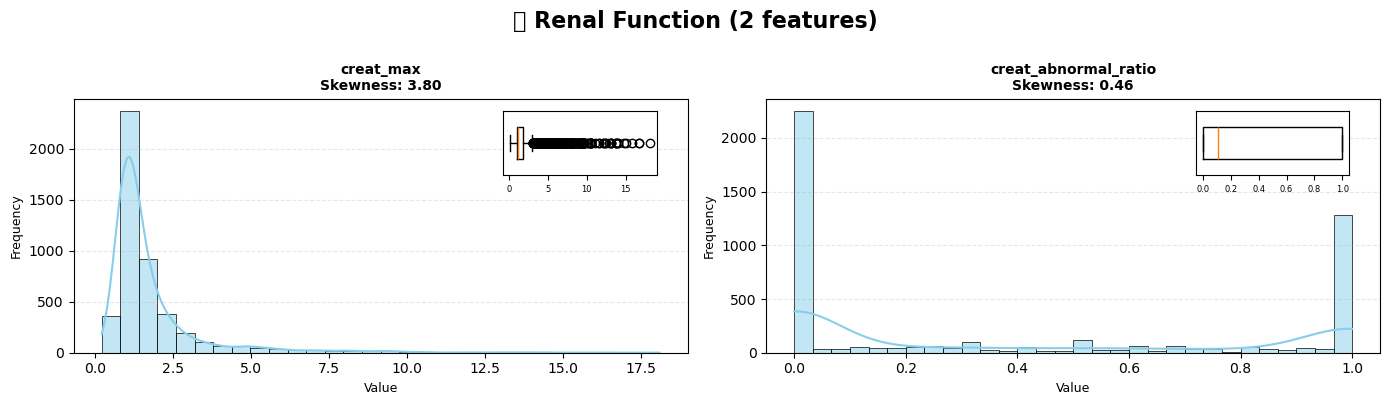


Group: Renal Function

creat_max:
  • N values: 4694
  • Range: [0.20, 18.10]
  • Mean: 1.77 ± 1.66
  • Median: 1.20
  • Skewness: 3.80
  • % NaN: 0.0%

creat_abnormal_ratio:
  • N values: 4694
  • Range: [0.00, 1.00]
  • Mean: 0.39 ± 0.44
  • Median: 0.11
  • Skewness: 0.46
  • % NaN: 0.0%




/tmp/ipykernel_99669/515726874.py:51: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/gabriele/miniconda3/envs/DADH/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


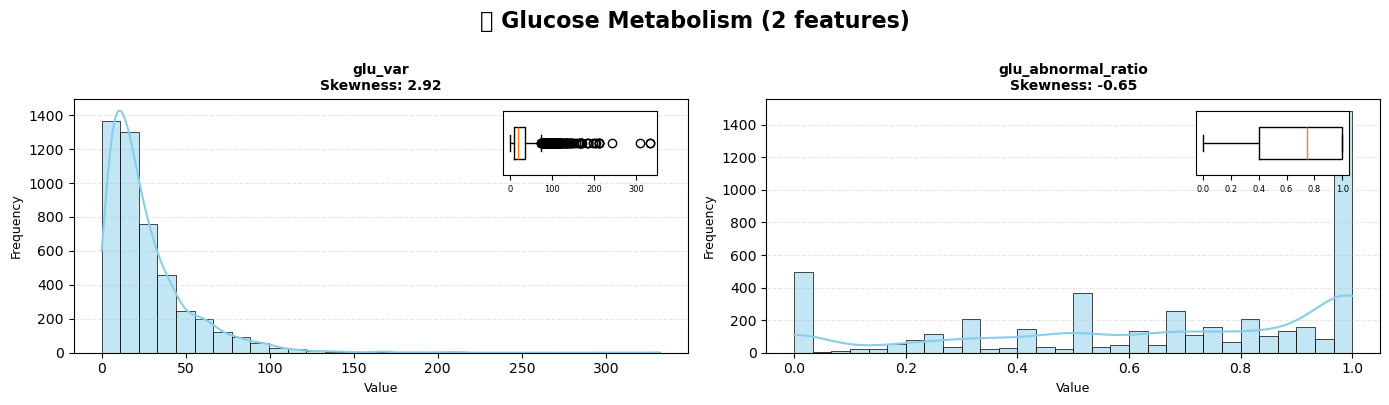


Group: Glucose Metabolism

glu_var:
  • N values: 4694
  • Range: [0.00, 331.98]
  • Mean: 26.98 ± 26.65
  • Median: 18.88
  • Skewness: 2.92
  • % NaN: 0.0%

glu_abnormal_ratio:
  • N values: 4694
  • Range: [0.00, 1.00]
  • Mean: 0.66 ± 0.34
  • Median: 0.75
  • Skewness: -0.65
  • % NaN: 0.0%




/tmp/ipykernel_99669/515726874.py:51: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/gabriele/miniconda3/envs/DADH/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


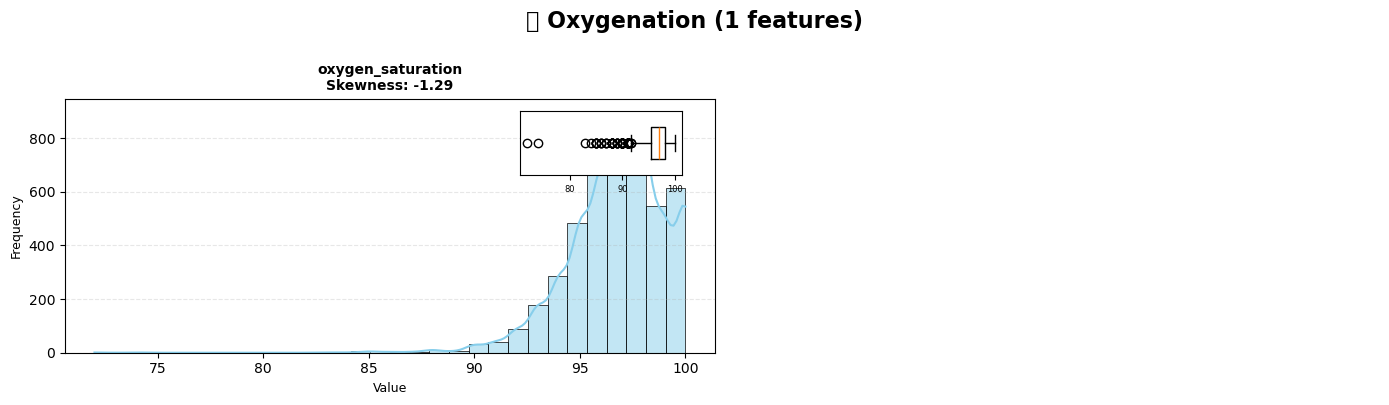


Group: Oxygenation

oxygen_saturation:
  • N values: 4694
  • Range: [72.00, 100.00]
  • Mean: 96.80 ± 2.34
  • Median: 97.00
  • Skewness: -1.29
  • % NaN: 0.0%




/tmp/ipykernel_99669/515726874.py:51: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/gabriele/miniconda3/envs/DADH/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


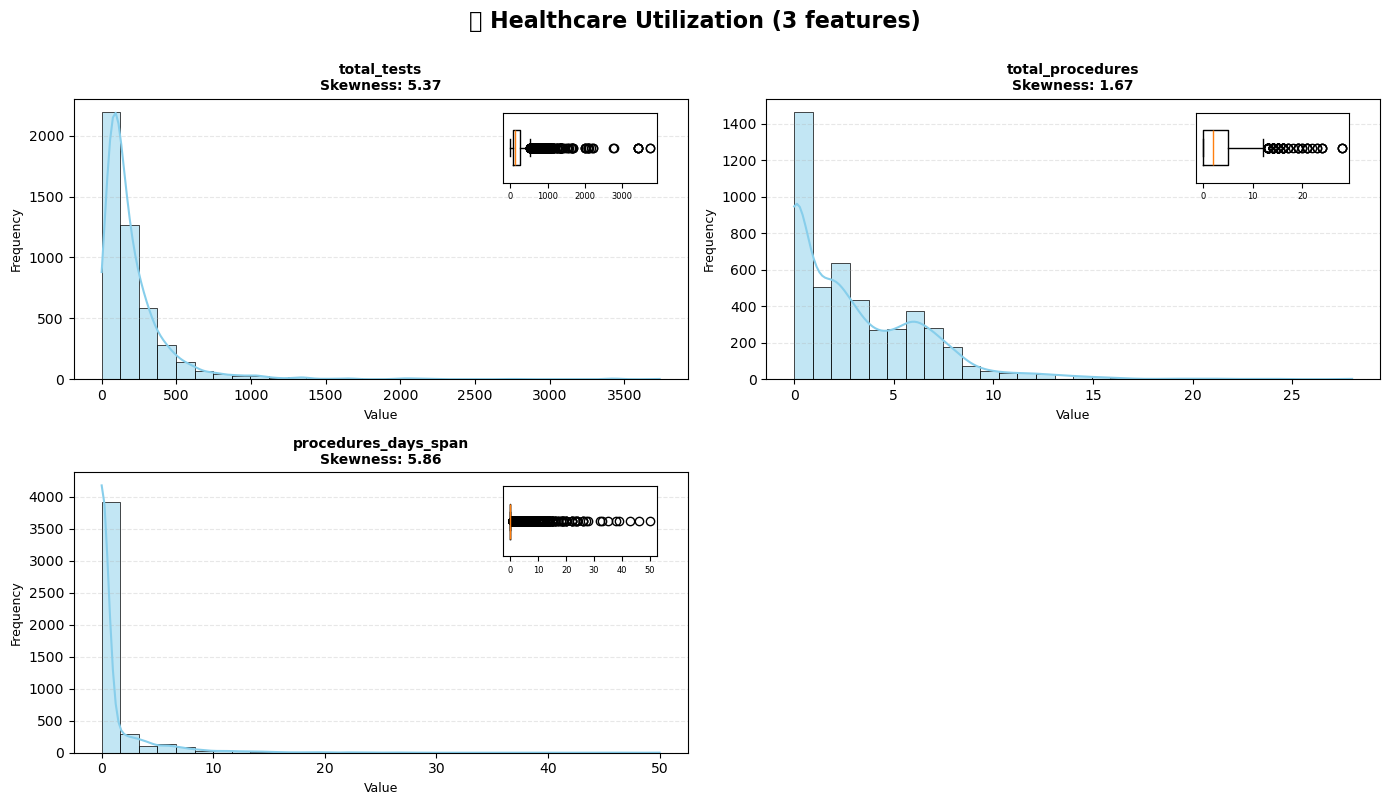

/tmp/ipykernel_99669/515726874.py:51: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()



Group: Healthcare Utilization

total_tests:
  • N values: 4694
  • Range: [0.00, 3737.00]
  • Mean: 213.28 ± 265.36
  • Median: 135.00
  • Skewness: 5.37
  • % NaN: 0.0%

total_procedures:
  • N values: 4694
  • Range: [0.00, 28.00]
  • Mean: 3.09 ± 3.44
  • Median: 2.00
  • Skewness: 1.67
  • % NaN: 0.0%

procedures_days_span:
  • N values: 4694
  • Range: [0.00, 50.00]
  • Mean: 1.06 ± 3.23
  • Median: 0.00
  • Skewness: 5.86
  • % NaN: 0.0%




/home/gabriele/miniconda3/envs/DADH/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


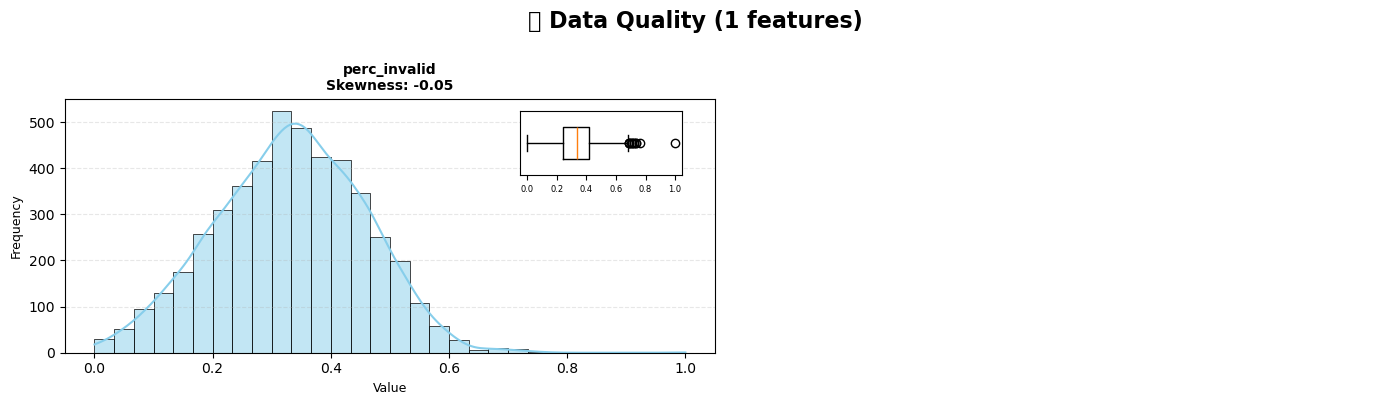


Group: Data Quality

perc_invalid:
  • N values: 4694
  • Range: [0.00, 1.00]
  • Mean: 0.33 ± 0.13
  • Median: 0.33
  • Skewness: -0.05
  • % NaN: 0.0%




In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

for group_name, features in feature_groups.items():
    existing_features = [f for f in features if f in patient_profiles_clean.columns]
    
    if not existing_features:
        continue
    
    n_cols = 2
    n_rows = (len(existing_features) + 1) // 2
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4*n_rows))
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    
    axes = axes.flatten()

    for i, col in enumerate(existing_features):
        ax = axes[i]
        
        data = patient_profiles_clean[col].dropna()
        
        if len(data) == 0:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f"{col}\n(No data)", fontsize=10)
            continue
        
        sns.histplot(data, kde=True, bins=30, ax=ax, color='skyblue', edgecolor='black', linewidth=0.5)
        
        skew_val = skew(data)
        ax_box = ax.inset_axes([0.7, 0.7, 0.25, 0.25])
        ax_box.boxplot(data, vert=False, widths=0.5)
        ax_box.set_yticks([])
        ax_box.set_xlabel('')
        ax_box.tick_params(labelsize=6)
        
        ax.set_title(f"{col}\nSkewness: {skew_val:.2f}", fontsize=10, fontweight='bold')
        ax.set_xlabel('Value', fontsize=9)
        ax.set_ylabel('Frequency', fontsize=9)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Hide unused axes
    for j in range(len(existing_features), len(axes)):
        axes[j].axis('off')
    
    # Main title
    plt.suptitle(f'📊 {group_name} ({len(existing_features)} features)', 
                 fontsize=16, fontweight='bold', y=1.00)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n{'='*80}")
    print(f"Group: {group_name}")
    print(f"{'='*80}")
    
    # Print statistics for each feature
    for col in existing_features:
        data = patient_profiles_clean[col].dropna()
        if len(data) > 0:
            print(f"\n{col}:")
            print(f"  • N values: {len(data)}")
            print(f"  • Range: [{data.min():.2f}, {data.max():.2f}]")
            print(f"  • Mean: {data.mean():.2f} ± {data.std():.2f}")
            print(f"  • Median: {data.median():.2f}")
            print(f"  • Skewness: {skew(data):.2f}")
            print(f"  • % NaN: {(patient_profiles_clean[col].isna().sum() / len(patient_profiles_clean) * 100):.1f}%")
    
    print(f"\n{'='*80}\n")


In [44]:
skewness = patient_profiles_clean[features_cols].skew()
skewed_features = skewness[abs(skewness) > 1].index.tolist()

print(f"Features with skewness > 1: {len(skewed_features)}")
print("\nSkewness per feature:")
print(skewness[abs(skewness) > 1].sort_values(ascending=False))

Features with skewness > 1: 12

Skewness per feature:
procedures_days_span             5.857397
total_tests                      5.367861
hemodynamic_instability_score    4.952787
creat_max                        3.800059
k_abnormal_ratio                 3.720115
glu_var                          2.925127
na_abnormal_ratio                2.902366
k_max                            1.792645
cl_abnormal_ratio                1.762413
total_procedures                 1.671175
na_min                          -1.236291
oxygen_saturation               -1.295373
dtype: float64


In [45]:
import numpy as np
from scipy.stats import boxcox, yeojohnson
from scipy.stats import skew

def transform_skewed_feature(series, skew_value, method='auto'):
    """
    Advanced feature transformation based on skewness value and data characteristics.
    
    Rules:
    - Skew > 3: Yeo-Johnson (optimal power transformation)
    - 1.5 < Skew <= 3: Box-Cox or sqrt (depends on data range)
    - 1 < Skew <= 1.5: Square root (gentle transformation)
    - |Skew| <= 1: No transformation
    - Skew < -1: Reflect + appropriate transformation
    
    Parameters:
    -----------
    series : pd.Series
        The feature to transform
    skew_value : float
        The skewness value
    method : str
        'auto' (default), 'boxcox', 'yeojohnson', 'sqrt', 'log'
    
    Returns:
    --------
    transformed : pd.Series
        The transformed series
    transformation_name : str
        Description of the transformation applied
    """
    
    transformed = series.copy()
    non_null_mask = transformed.notna()
    non_null_data = transformed[non_null_mask]
    
    if len(non_null_data) == 0:
        return transformed, 'no_transform (all NaN)'
    
    # Calculate data characteristics
    data_min = non_null_data.min()
    data_max = non_null_data.max()
    data_range = data_max - data_min
    has_zeros = (non_null_data == 0).any()
    has_negatives = (non_null_data < 0).any()
    
    
    if skew_value > 1:
        if skew_value > 3 or method == 'yeojohnson':
            try:
                transformed_data, lambda_param = yeojohnson(non_null_data)
                transformed[non_null_mask] = transformed_data
                return transformed, f'yeojohnson (λ={lambda_param:.3f})'
            except:
                pass  # Fallback to next method
        
        if 1.5 < skew_value <= 3:
            if data_max < 100 or method == 'boxcox':
                try:
                    # Handle zeros and negatives for Box-Cox
                    if has_negatives or has_zeros:
                        shift = abs(data_min) + 1
                        data_shifted = non_null_data + shift
                        transformed_data, lambda_param = boxcox(data_shifted)
                        transformed[non_null_mask] = transformed_data
                        return transformed, f'boxcox (λ={lambda_param:.3f}, shift={shift:.2f})'
                    else:
                        transformed_data, lambda_param = boxcox(non_null_data)
                        transformed[non_null_mask] = transformed_data
                        return transformed, f'boxcox (λ={lambda_param:.3f})'
                except:
                    # Fallback to sqrt
                    if has_negatives:
                        shift = abs(data_min) + 1
                        transformed[non_null_mask] = np.sqrt(non_null_data + shift)
                        return transformed, f'sqrt (shifted by {shift:.2f})'
                    else:
                        transformed[non_null_mask] = np.sqrt(non_null_data)
                        return transformed, 'sqrt'
        
        if 1 < skew_value <= 1.5 or method == 'sqrt':
            if has_negatives:
                shift = abs(data_min) + 1
                transformed[non_null_mask] = np.sqrt(non_null_data + shift)
                return transformed, f'sqrt (shifted by {shift:.2f})'
            else:
                transformed[non_null_mask] = np.sqrt(non_null_data)
                return transformed, 'sqrt'
        
        if has_negatives:
            shift = abs(data_min) + 1
            transformed[non_null_mask] = np.log1p(non_null_data + shift)
            return transformed, f'log1p (shifted by {shift:.2f})'
        else:
            transformed[non_null_mask] = np.log1p(non_null_data)
            return transformed, 'log1p'
    
    elif skew_value < -1:
        # Reflect the data
        max_val = non_null_data.max()
        reflected = max_val - non_null_data
        if abs(skew_value) > 3:
            try:
                transformed_data, _ = yeojohnson(reflected)
                transformed[non_null_mask] = transformed_data
                return transformed, 'reflect + yeojohnson'
            except:
                pass
        
        if abs(skew_value) > 1.5:
            transformed[non_null_mask] = np.sqrt(reflected + 1)
            return transformed, 'reflect + sqrt'
        else:
            transformed[non_null_mask] = np.log1p(reflected)
            return transformed, 'reflect + log1p'
    
    else:
        return transformed, 'no_transform (skewness acceptable)'



def transform_all_skewed_features(df, skew_threshold=1.0, exclude_cols=None, method='auto'):
    """
    Apply appropriate transformations to all skewed features in a dataframe.
    
    Parameters:
    -----------
    df : pd.DataFrame
        The dataframe with features
    skew_threshold : float
        Minimum skewness to trigger transformation (default: 1.0)
    exclude_cols : list
        Columns to exclude from transformation
    method : str
        Transformation method: 'auto', 'boxcox', 'yeojohnson', 'sqrt', 'log'
    
    Returns:
    --------
    df_transformed : pd.DataFrame
        Dataframe with transformed features
    transformation_info : dict
        Information about transformations applied
    """
    
    if exclude_cols is None:
        exclude_cols = []
    
    df_transformed = df.copy()
    transformation_info = {}
    
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    numeric_cols = [col for col in numeric_cols if col not in exclude_cols]
    
    for col in numeric_cols:
        data = df[col].dropna()
        
        if len(data) == 0:
            continue
        
        original_skew = skew(data)
        
        if abs(original_skew) > skew_threshold:
            # Apply transformation
            transformed_col, transform_name = transform_skewed_feature(
                df[col], 
                original_skew,
                method=method
            )
            
            # Calculate new skewness
            new_skew = skew(transformed_col.dropna())
            improvement = abs(original_skew) - abs(new_skew)
            
            # Update dataframe
            df_transformed[col] = transformed_col
            
            # Store info
            transformation_info[col] = {
                'method': transform_name,
                'original_skew': original_skew,
                'new_skew': new_skew,
                'improvement': improvement
            }
    
    return df_transformed, transformation_info


In [46]:
df_transformed, info = transform_all_skewed_features(
    patient_profiles_clean,
    skew_threshold=1.0,
    exclude_cols=['subject_id'],
    method='auto'
)

In [47]:
for col, details in info.items():
    print(f"{col}: {details['method']} → improvement: {details['improvement']:.2f}")

glu_var: log1p → improvement: 2.68
hemodynamic_instability_score: yeojohnson (λ=-12.359) → improvement: 2.14
na_abnormal_ratio: boxcox (λ=-12.044, shift=1.00) → improvement: 1.64
cl_abnormal_ratio: boxcox (λ=-5.611, shift=1.00) → improvement: 1.03
na_min: reflect + log1p → improvement: 0.86
creat_max: yeojohnson (λ=-1.679) → improvement: 3.63
k_abnormal_ratio: yeojohnson (λ=-18.784) → improvement: 2.48
k_max: boxcox (λ=-0.982) → improvement: 1.52
total_tests: yeojohnson (λ=0.035) → improvement: 5.35
total_procedures: boxcox (λ=-0.045, shift=1.00) → improvement: 1.65
procedures_days_span: yeojohnson (λ=-2.725) → improvement: 4.44
oxygen_saturation: reflect + log1p → improvement: 0.66


In [48]:
# Save the processed dataset
output_path = 'patient_profiles.csv'
df_transformed.to_csv(Path().resolve().parent / 'Features' / output_path, index=False)